In [2]:
import pandas as pd

df = pd.read_csv("cybersecurity_intrusion_data.csv")

df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   str    
 1   network_packet_size  9537 non-null   int64  
 2   protocol_type        9537 non-null   str    
 3   login_attempts       9537 non-null   int64  
 4   session_duration     9537 non-null   float64
 5   encryption_used      7571 non-null   str    
 6   ip_reputation_score  9537 non-null   float64
 7   failed_logins        9537 non-null   int64  
 8   browser_type         9537 non-null   str    
 9   unusual_time_access  9537 non-null   int64  
 10  attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(5), str(4)
memory usage: 819.7 KB


,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected
count,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000,9537.000000
mean,500.430639,4.032086,792.745312,0.331338,1.517773,0.149942,0.447101
std,198.379364,1.963012,786.560144,0.177175,1.033988,0.357034,0.497220
min,64.000000,1.000000,0.500000,0.002497,0.000000,0.000000,0.000000
25%,365.000000,3.000000,231.953006,0.191946,1.000000,0.000000,0.000000
50%,499.000000,4.000000,556.277457,0.314778,1.000000,0.000000,0.000000
75%,635.000000,5.000000,1105.380602,0.453388,2.000000,0.000000,1.000000
max,1285.000000,13.000000,7190.392213,0.924299,5.000000,1.000000,1.000000


In [3]:
import numpy as np

df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

In [4]:
df = pd.get_dummies(df, drop_first=True)

In [5]:
df.columns.tolist()

['network_packet_size',
 'login_attempts',
 'session_duration',
 'ip_reputation_score',
 'failed_logins',
 'unusual_time_access',
 'attack_detected',
 'session_id_SID_00002',
 'session_id_SID_00003',
 'session_id_SID_00004',
 'session_id_SID_00005',
 'session_id_SID_00006',
 'session_id_SID_00007',
 'session_id_SID_00008',
 'session_id_SID_00011',
 'session_id_SID_00012',
 'session_id_SID_00014',
 'session_id_SID_00016',
 'session_id_SID_00017',
 'session_id_SID_00019',
 'session_id_SID_00020',
 'session_id_SID_00021',
 'session_id_SID_00023',
 'session_id_SID_00024',
 'session_id_SID_00025',
 'session_id_SID_00026',
 'session_id_SID_00028',
 'session_id_SID_00029',
 'session_id_SID_00030',
 'session_id_SID_00031',
 'session_id_SID_00032',
 'session_id_SID_00034',
 'session_id_SID_00036',
 'session_id_SID_00038',
 'session_id_SID_00039',
 'session_id_SID_00040',
 'session_id_SID_00042',
 'session_id_SID_00043',
 'session_id_SID_00045',
 'session_id_SID_00046',
 'session_id_SID_00047',


In [6]:
X = df.drop(['attack_detected'], axis=1)
y = df['attack_detected']

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [10]:
y_pred = model.predict(X_test)

In [11]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9003300330033003
              precision    recall  f1-score   support

           0       0.85      1.00      0.92       841
           1       1.00      0.78      0.87       674

    accuracy                           0.90      1515
   macro avg       0.92      0.89      0.90      1515
weighted avg       0.92      0.90      0.90      1515



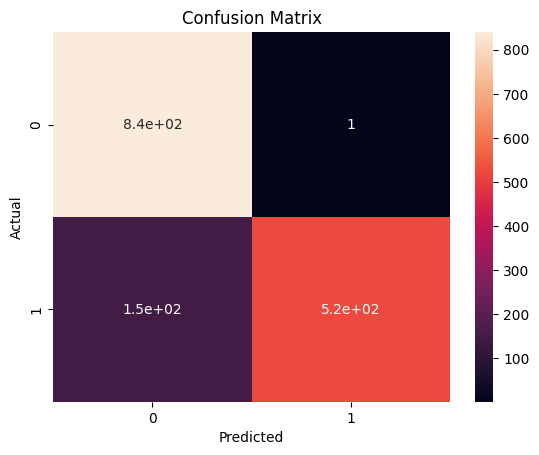

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [13]:
import pandas as pd

feature_importances = model.feature_importances_

features_df = pd.DataFrame({
    'feature': X.columns,
    'importance': feature_importances
})

features_df = features_df.sort_values('importance', ascending=False)

features_df.head(10)

,feature,importance
4,failed_logins,0.226085
1,login_attempts,0.152809
3,ip_reputation_score,0.133249
2,session_duration,0.031019
0,network_packet_size,0.026861
7582,browser_type_Unknown,0.020110
7578,encryption_used_DES,0.003866
5,unusual_time_access,0.003416
7580,browser_type_Firefox,0.002663
7579,browser_type_Edge,0.002599


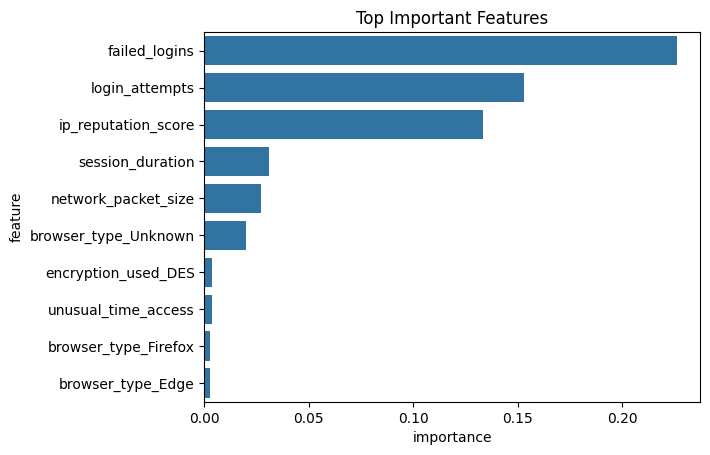

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.barplot(x='importance', y='feature', data=features_df.head(10))
plt.title("Top Important Features")
plt.show()

<Axes: xlabel='attack_detected'>

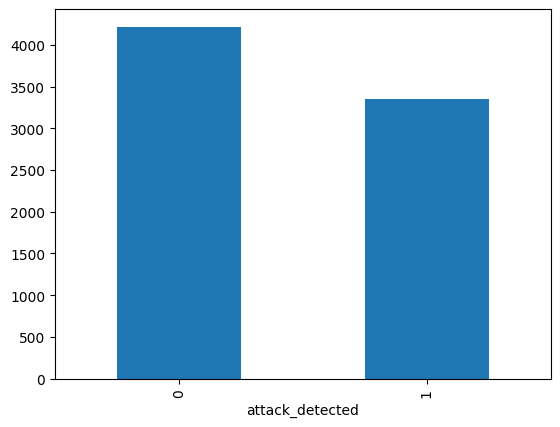

In [15]:
df['attack_detected'].value_counts().plot(kind='bar')

In [16]:
df = df.drop(columns=[col for col in df.columns if col.startswith('session_id')])

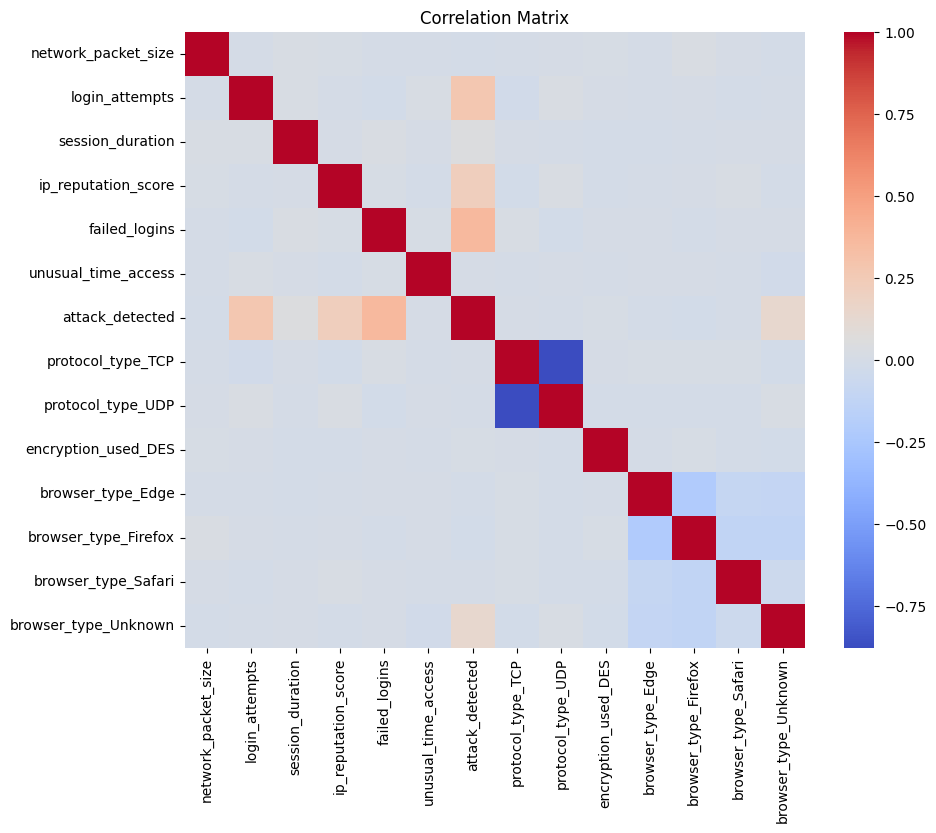

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

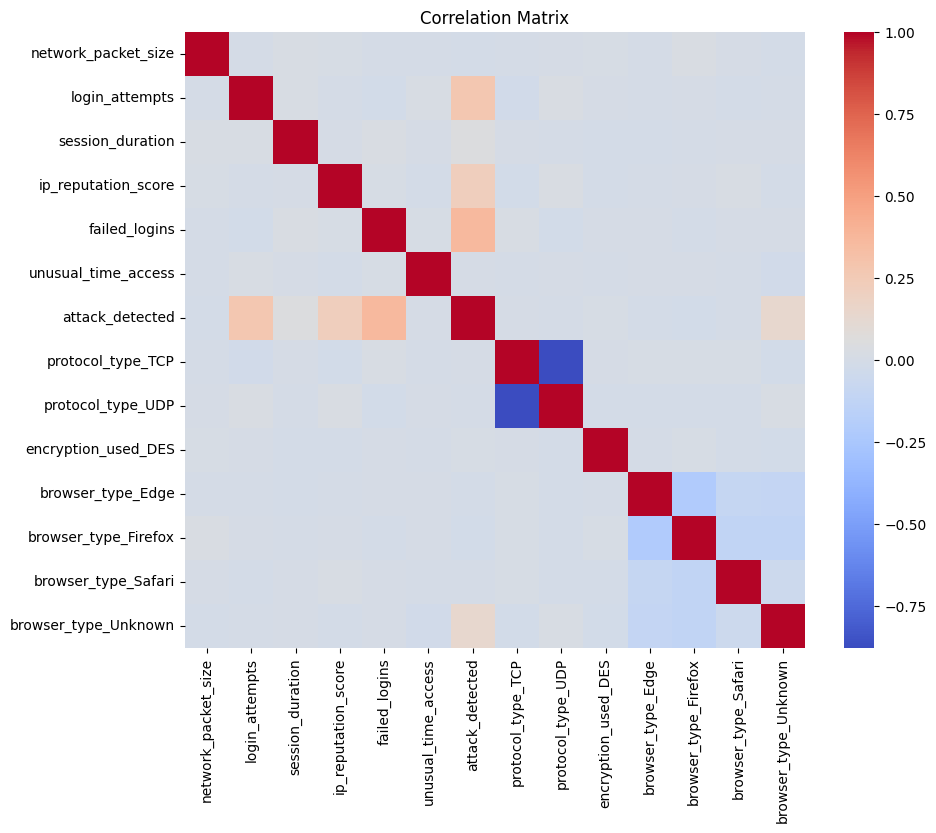

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

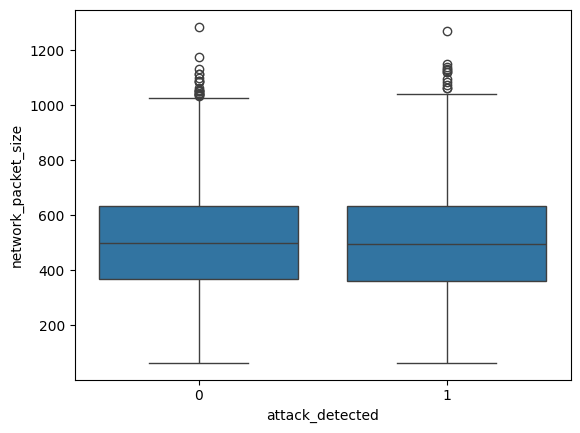

In [19]:
sns.boxplot(x='attack_detected', y='network_packet_size', data=df)
plt.show()

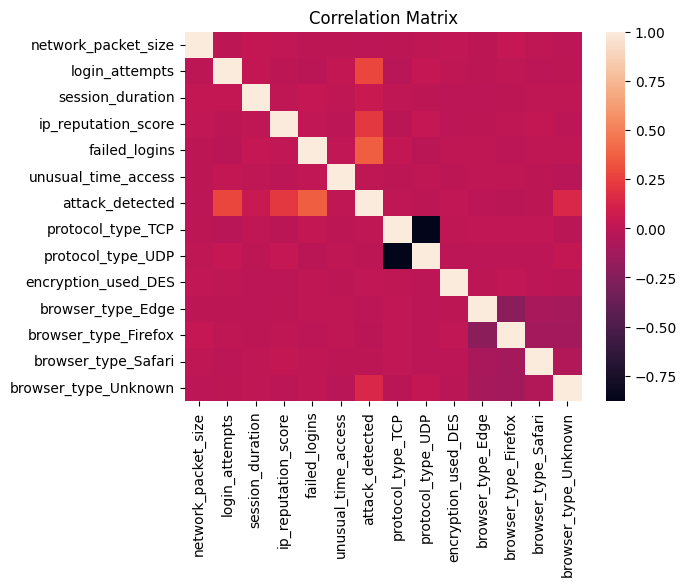

In [20]:
plt.figure()
sns.heatmap(df.corr())
plt.title("Correlation Matrix")
plt.show()